# Analysis of simulated trajectorories

In [2]:
cd ~/work/tutorials/sources/OpenDrift/openberg_july2026

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026


In [3]:
# import pandas as pd
# import xarray as xr
# import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import glob
from src.utils import *
from openberg_july2026.src2.utils2 import *

In [4]:
# # test = xr.open_dataset('./input/gebco_2026_n85.0_s35.0_w-80.0_e0.0.nc')
# test['sea_floor_depth_below_sea_level'] = (('lat','lon'),-test.elevation.data)
# test.sea_floor_depth_below_sea_level.attrs['standard_name']='sea_floor_depth_below_sea_level'
# test.sea_floor_depth_below_sea_level.plot()

['./results/iceberg2011w1_gebco_topaz4_windglophyre.nc', './results/iceberg2011w1_gebco_topaz4_waverys_windglophyre.nc']


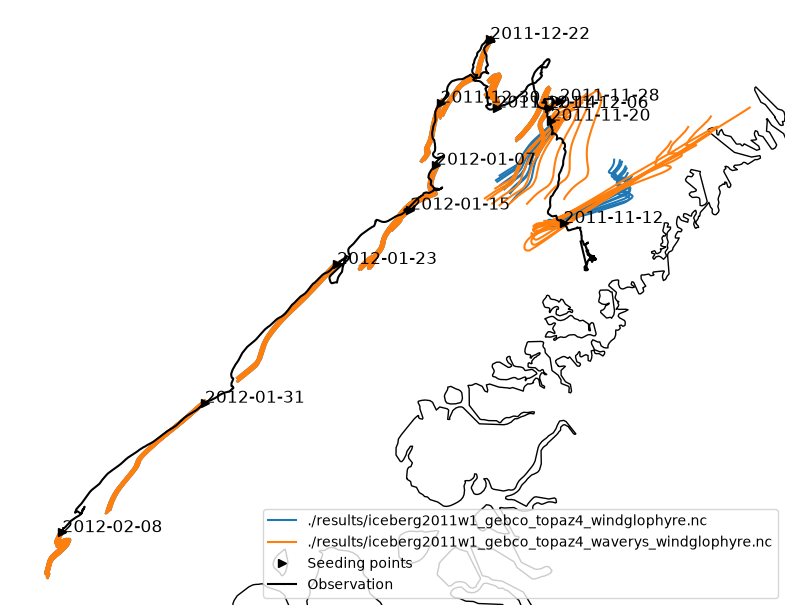

In [8]:
#very simple plot of simulations
ib = 'iceberg2011w1'

#read obs
with xr.open_dataset('./input/merged_obs3.nc') as ds:
    obs = ds.sel(iceberg=ib,trajectory_id=ib) 
    #obs = obs.isel(time=(obs.seed_idx==1))

#read sim
file_contain_all = [ib,'topaz']
file_contain_any = ['_']
file_notcontain = ['test','next',]#['topaz4','glorys','slope','era5','almost','stokes',]
file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l = file_l#[::-1]
print(file_l)
#Figure
fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo()})#central_longitude=20})
ax.coastlines(resolution='10m')
trans = ccrs.PlateCarree()

cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
col = cmap(np.linspace(0, 1, 20))[::2]#20 colors
# plot sim
for inputdataidx, inputdata in enumerate(file_l):
    sim = xr.open_dataset(inputdata)
    for traj in sim.trajectory:
        ax.plot(sim.lon.sel(trajectory=traj).dropna(dim="time"),sim.lat.sel(trajectory=traj).dropna(dim="time"),
                color=col[inputdataidx],
                label=inputdata if traj==sim.trajectory[0] else '',
            transform=trans)

# # plot obs
ax.plot(obs['lon'].isel(time=(obs.seed_idx==1)),obs['lat'].isel(time=(obs.seed_idx==1)),'>',transform=trans,color='k',label='Seeding points')
ax.plot(obs['lon'],obs['lat'],transform=trans,color='k',label='Observation')
# for d in range(obs_3day['time'].size):
for d in range(obs['time'].isel(time=(obs.seed_idx==1)).size):
#     if d not in [1,2,3,4,5,12,15,16,17,18,19]:
        ax.text(obs['lon'].isel(time=(obs.seed_idx==1))[d],obs['lat'].isel(time=(obs.seed_idx==1))[d],obs['time'].isel(time=(obs.seed_idx==1))[d].values.astype('datetime64[D]').astype(str),transform=trans,color='k',fontsize=12)

plt.legend()
plt.axis('off')
plt.show()



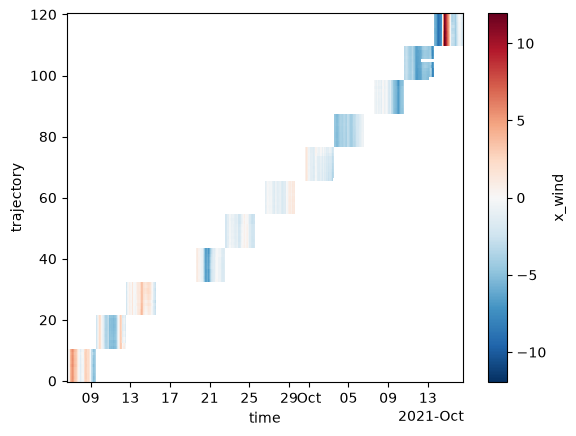

In [18]:
# np.sum((sim.x_wind!=0.0) & (np.isnan(sim.x_wind)==False))
sim.x_wind.plot()




In [3]:
# Read and subset tracker data
obs_3day = read_tracker('./input/Osker-X2.csv')['3D']
obs = read_tracker('./input/Osker-X2.csv')['full']

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:109: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette/src/utils2.py:109: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [5]:
# --- Which simulation data for plot? ---
# note = False
# file_contain_all = ['_']
# file_contain_any = ['_']
# file_notcontain = ['topaz4','glorys','slope','era5','almost','stokes',]
# file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
# file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
# file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
# file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l = ['nextsimanfc_glophyanfc_waverys_windglophynrt', 'nextsimanfc_glophyanfc_mfwam_windglophynrt', 'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt', 
          'nextsimanfc_topaz6_topaz5_waverys_windglophynrt', 'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt', 'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt', 
          'nextsimanfc_topaz5_waverys_windglophynrt', 'nextsimanfc_topaz5_mfwam_windglophynrt', 'nextsimanfc_topaz5_arcmfcwam_windglophynrt', 
          'glophyanfc_waverys_windglophynrt', 'topaz6_topaz5_waverys_windglophynrt', 'topaz5_waverys_windglophynrt' ,'nextsim']
file_l

['nextsimanfc_glophyanfc_waverys_windglophynrt',
 'nextsimanfc_glophyanfc_mfwam_windglophynrt',
 'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt',
 'nextsimanfc_topaz6_topaz5_waverys_windglophynrt',
 'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt',
 'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt',
 'nextsimanfc_topaz5_waverys_windglophynrt',
 'nextsimanfc_topaz5_mfwam_windglophynrt',
 'nextsimanfc_topaz5_arcmfcwam_windglophynrt',
 'glophyanfc_waverys_windglophynrt',
 'topaz6_topaz5_waverys_windglophynrt',
 'topaz5_waverys_windglophynrt',
 'nextsim']

In [6]:
# # --- Open all simulation results in one dataset --- 
# with xr.open_mfdataset(
#     file_l,
#     combine="nested",
#     concat_dim="run",
#     parallel=True,
#     engine="netcdf4",
#     # chunks={'time': 10}
# ) as simall: 
#     simall = simall.assign_coords(run=file_l)  # or any list of labels

In [7]:
# # --- find trajectories
# # by seeding length
# seedinglengths = np.nanmax(simall.length[0,:,:],axis=1)
# seedinglengths_unq = np.unique(seedinglengths)
# print(seedinglengths_unq)
# seedinglengths_dict = {v: np.where(seedinglengths == v)[0].tolist() for v in seedinglengths_unq}
# trajs = np.array([seedinglengths_dict[sl] for sl in seedinglengths_unq[2:]]).flatten()

# #by time
# trajs = np.arange(0,10*10+1) #PART1
# print(trajs, simall.sel(trajectory=trajs).time[np.array([0,-1])].values, np.unique(seedinglengths[trajs]))
# traj = False
# # note = 'wave_only_o300length'

In [8]:
runtrajdict = {#for analysis of part I and II [timestep: 0-10,11-19]
             'nextsimanfc_glophyanfc_waverys_windglophynrt':np.arange(0,26*10),
             'nextsimanfc_glophyanfc_mfwam_windglophynrt':np.arange(0,20*10),
             'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt':np.arange(0,20*10),
             'nextsimanfc_topaz5_waverys_windglophynrt':np.arange(0,20*10),
             'nextsimanfc_topaz5_mfwam_windglophynrt':np.arange(0,20*10),
             'nextsimanfc_topaz5_arcmfcwam_windglophynrt':np.arange(0,20*10),
             'nextsimanfc_topaz6_topaz5_waverys_windglophynrt':np.arange(0,20*10),
             'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt':np.arange(0,20*10),
             'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt':np.arange(0,20*10),
            #for analysis of part III
              # 'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt':np.arange(20*10,26*10), #2nd
             'glophyanfc_waverys_windglophynrt':np.arange(20*10,26*10),
             'topaz5_waverys_windglophynrt':np.arange(20*10,26*10),
             'topaz6_topaz5_waverys_windglophynrt':np.arange(20*10,26*10),#maybe change ideces here to matchdifferent counting
            'nextsim':np.arange(20*10,26*10),
}
colordict = {#for analysis of part I and II
             'nextsimanfc_glophyanfc_waverys_windglophynrt':{'col':'orange','alpha':1,'kw':'Glophyanfc'},
             'nextsimanfc_glophyanfc_mfwam_windglophynrt':{'col':'orange','alpha':0.7,'kw':'Glophyanfc'},
             'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt':{'col':'orange','alpha':0.4,'kw':'Glophyanfc'},
             'nextsimanfc_topaz5_waverys_windglophynrt':{'col':'cyan','alpha':1,'kw':'TOPAZ5'},
             'nextsimanfc_topaz5_mfwam_windglophynrt':{'col':'cyan','alpha':0.7,'kw':'TOPAZ5'},
             'nextsimanfc_topaz5_arcmfcwam_windglophynrt':{'col':'cyan','alpha':0.4,'kw':'TOPAZ5'},
             'nextsimanfc_topaz6_topaz5_waverys_windglophynrt':{'col':'green','alpha':1,'kw':'TOPAZ6+5'},
             'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt':{'col':'green','alpha':0.7,'kw':'TOPAZ6+5'},
             'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt':{'col':'green','alpha':0.4,'kw':'TOPAZ6+5'},
            #for analysis of part III
             'nextsim':{'col':'red','alpha':1,'kw':'neXtSIM'},
             'glophyanfc_waverys_windglophynrt':{'col':'orange','alpha':1,'kw':'Glophyanfc'},
             'topaz5_waverys_windglophynrt':{'col':'cyan','alpha':1,'kw':'TOPAZ5'},
             'topaz6_topaz5_waverys_windglophynrt':{'col':'green','alpha':1,'kw':'TOPAZ6+5'},
}
legenddict = {              
            'Simulations with input by: \nneXtSIM':{'col':'red','alpha':1},
            'Glophyanfc':{'col':'orange','alpha':1},
              'TOPAZ5':{'col':'cyan','alpha':1},
              'TOPAZ6+5':{'col':'green','alpha':1},
              'WAVERYS (alpha=1)':{'col':'green','alpha':1},
              'MFWAM (alpha=0.7)':{'col':'green','alpha':0.7},
              'ARCMFCWAM (alpha=0.4)':{'col':'green','alpha':0.4},
             }

0 nextsimanfc_glophyanfc_waverys_windglophynrt {'col': 'orange', 'alpha': 1, 'kw': 'Glophyanfc'}
1 nextsimanfc_glophyanfc_mfwam_windglophynrt {'col': 'orange', 'alpha': 0.7, 'kw': 'Glophyanfc'}
2 nextsimanfc_glophyanfc_arcmfcwam_windglophynrt {'col': 'orange', 'alpha': 0.4, 'kw': 'Glophyanfc'}
3 nextsimanfc_topaz6_topaz5_waverys_windglophynrt {'col': 'green', 'alpha': 1, 'kw': 'TOPAZ6+5'}
4 nextsimanfc_topaz6_topaz5_mfwam_windglophynrt {'col': 'green', 'alpha': 0.7, 'kw': 'TOPAZ6+5'}
5 nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt {'col': 'green', 'alpha': 0.4, 'kw': 'TOPAZ6+5'}
6 nextsimanfc_topaz5_waverys_windglophynrt {'col': 'cyan', 'alpha': 1, 'kw': 'TOPAZ5'}
7 nextsimanfc_topaz5_mfwam_windglophynrt {'col': 'cyan', 'alpha': 0.7, 'kw': 'TOPAZ5'}
8 nextsimanfc_topaz5_arcmfcwam_windglophynrt {'col': 'cyan', 'alpha': 0.4, 'kw': 'TOPAZ5'}
9 glophyanfc_waverys_windglophynrt {'col': 'orange', 'alpha': 1, 'kw': 'Glophyanfc'}
10 topaz6_topaz5_waverys_windglophynrt {'col': 'green', 'alp

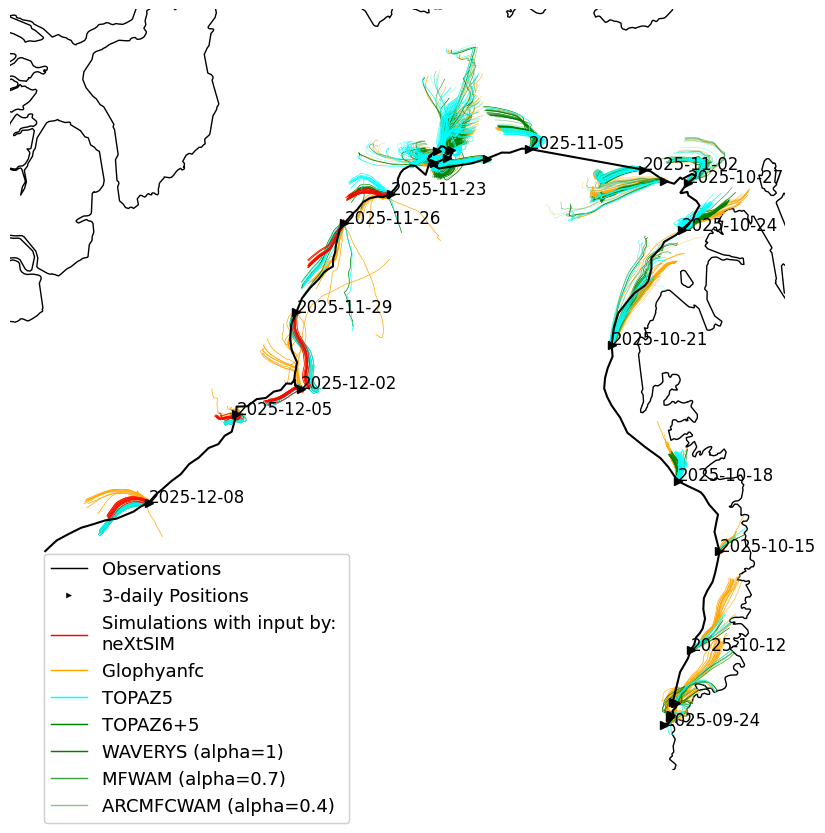

In [9]:
# Map plot comparing simulations with different input

#def
url_letters, note_letters, fileending_letters = 19,8,3
note = 'all'
#by = inputdataidx
# cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
# col = cmap(np.linspace(0, 1, 20))[::2]#20 colors


#Figure
fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo()})#central_longitude=20})
ax.coastlines(resolution='10m')
trans = ccrs.PlateCarree()
#ax.set_extent((-42.5, -11, 65, 78))

# plot sim
#version that reads from join simall datset
# for inputdataidx, inputdataurl in enumerate(simall.run.values):
#     inputdata = inputdataurl[url_letters:-(note_letters+fileending_letters)]
#     print(inputdataidx, inputdata,colordict[inputdata])
    # for traj in runtrajdict[inputdata]:# trajs if traj else simall.trajectory:
    #     plotcol = colordict['nextsim']['col'] if np.logical_and(inputdata=='nextsimanfc_glophyanfc_waverys_windglophynrt',traj in np.arange(10*20,26*10,1)) else colordict[inputdata]['col']
    #     ax.plot(simall.lon.sel(run=inputdataurl,trajectory=traj).dropna(dim="time"),simall.lat.sel(run=inputdataurl,trajectory=traj).dropna(dim="time"),
    #     color= plotcol,
    #     alpha=colordict[inputdata]['alpha'],#col[inputdataidx],
    #     linewidth=0.5,
    #     transform=trans)
    #version that open up every sim results individually (faster)
for inputdataidx, inputdata in enumerate(file_l):
    sim = xr.open_dataset('./results/juliette_%s_wavedir.nc'%(inputdata if inputdata!='nextsim' else 'nextsimanfc_glophyanfc_waverys_windglophynrt'))
    plot_col = colordict[inputdata]['col']
    print(inputdataidx, inputdata ,colordict[inputdata])
    for traj in runtrajdict[inputdata]:
        # plotcol = colordict['nextsim']['col'] if np.logical_and(inputdata=='nextsimanfc_glophyanfc_waverys_windglophynrt',traj in np.arange(10*20,26*10,1)) else colordict[inputdata]['col']
        ax.plot(sim.lon.sel(trajectory=traj).dropna(dim="time"),sim.lat.sel(trajectory=traj).dropna(dim="time"),
            color= plot_col,
            alpha=colordict[inputdata]['alpha'],#col[inputdataidx],
            linewidth=0.5,
            transform=trans)

# plot obs
ax.plot(obs_3day['lon'],obs_3day['lat'],'>',transform=trans,color='k')
ax.plot(obs['lon'],obs['lat'],transform=trans,color='k',label='Observation')
# for d in range(obs_3day['time'].size):
for d in range(obs_3day.time.size):
    if d not in [1,2,3,4,5,12,15,16,17,18,19]:
        ax.text(obs_3day['lon'][d],obs_3day['lat'][d],obs_3day['time'][d].values.astype('datetime64[D]').astype(str),transform=trans,color='k',fontsize=12)

#legend
legend_elements = [Line2D([0], [0],linestyle='-', color='k', lw=1,label='Observations'),
                  Line2D([0], [0],linestyle='-', color='w',marker='>',markerfacecolor='k', lw=1,label='3-daily Positions')]
# legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color=col[inputdataidx2], lw=1,
#                                           label=inputdata2[url_letters:-(note_letters+fileending_letters)].replace('_',', ').title() if inputdataidx2>0 else 'Simulations with input by: \n'+inputdata2[19:-3].replace('_',', ').title() )
#                                           for inputdataidx2,inputdata2 in enumerate(simall.run.values)]
legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color=legenddict[el]['col'],alpha=legenddict[el]['alpha'], lw=1, label=el) for el in legenddict]
leg = fig.legend(handles=legend_elements,bbox_to_anchor=(0.15, 0.34),loc='upper left',fontsize=13)#fontsize=fs,ncol=len(legend_elements0+legend_elements2),                  columnspacing=0.6,labelspacing=0.3,loc='center',bbox_to_anchor=bbox_dict[kw][0])
plt.axis('off')
fig.add_artist(leg)
if note!=False: plt.savefig('./results/analysis_juliette_map_%s.png'%note,dpi=200,transparent=True,bbox_inches='tight')
plt.show()



In [ ]:
# --- Checks on combined dataset of simulations results simall

# # --Check for variables from one "seeding round"
# # simall.length[0,np.arange(60,70),:].dropna(dim='time').shape 

# # --Check for variables at datetime
# simall_t1 = simall.sel(time=datetime(2025,10,18,0), method="nearest") 

# simall_t1_nan = simall_t1.dropna(
#     dim="trajectory",
#     # subset=["sea_surface_wave_from_direction"],
#     subset=["length"],
#     how="any" )
# # print(simall_t1_nan.run) #which runs
# #print (simall_t1_nan.trajectory) #which trajectory numbers
# # simall_t1_nan.sea_surface_wave_from_direction.values
# # simall_t1_nan.sea_surface_wave_significant_height.values
# # simall_t1_nan.sea_surface_wave_stokes_drift_x_velocity.plot()
# # simall_t1_nan.x_sea_water_velocity.values
# simall_t1_nan.sea_ice_area_fraction.plot()

# # simall_t1_nan.draft.values#[:,0].values


In [ ]:
# --- Checks on one simulation result file ---

# sim = xr.open_dataset('./results/juliette_topaz6_topaz5_waverys_windglophynrt_wavedir.nc')
# np.sum(np.isnan(sim.x_sea_water_velocity))/sim.x_sea_water_velocity.size
# sim_t1 = sim.sel(time=datetime(2025,10,21,0), method="nearest") 
# sim_t1.sea_surface_wave_from_direction.plot()
# sim.x_sea_water_velocity.plot()
# sim.attrs